ISABELLE WAKISA B30311 S24B38/019

1.Understanding the traffic density on various days of the week in the urban environments. [ 5 
MARKS ]

In [2]:
# importing the dataset and necessary libraries
import pandas as pd

df = pd.read_csv('Traffic_Data .csv')


In [3]:
# viewing the first 5 rows if the dataset
df.head()

,City,Vehicle Type,Weather,Economic Condition,Day Of Week,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density
0,SolarisVille,Drone,Snowy,Stable,Sunday,20,29.4268,0,0,14.7134,0.5241
1,AquaCity,Flying Car,Solar Flare,Recession,Wednesday,2,118.8000,0,0,143.5682,0.3208
2,Neuroburg,Autonomous Vehicle,Solar Flare,Recession,Wednesday,16,100.3904,0,0,91.2640,0.0415
3,Ecoopolis,Drone,Clear,Booming,Thursday,8,76.8000,1,0,46.0753,0.1811
4,AquaCity,Autonomous Vehicle,Solar Flare,Stable,Saturday,16,45.2176,0,0,40.1934,0.4544


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1219567 entries, 0 to 1219566
Data columns (total 11 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   City                   1219567 non-null  object 
 1   Vehicle Type           1219567 non-null  object 
 2   Weather                1219567 non-null  object 
 3   Economic Condition     1219567 non-null  object 
 4   Day Of Week            1219567 non-null  object 
 5   Hour Of Day            1219567 non-null  int64  
 6   Speed                  1219567 non-null  float64
 7   Is Peak Hour           1219567 non-null  int64  
 8   Random Event Occurred  1219567 non-null  int64  
 9   Energy Consumption     1219567 non-null  float64
 10  Traffic Density        1219567 non-null  float64
dtypes: float64(3), int64(3), object(5)
memory usage: 102.4+ MB


Data Preprocessing

In [7]:
# checking for any missing values
df.isna().sum()

City                     0
Vehicle Type             0
Weather                  0
Economic Condition       0
Day Of Week              0
Hour Of Day              0
Speed                    0
Is Peak Hour             0
Random Event Occurred    0
Energy Consumption       0
Traffic Density          0
dtype: int64

In [ ]:
# checking for outliers in continous variables
cont_data=df.select_dtypes(exclude="object")
cont_data.head()

,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density
0,20,29.4268,0,0,14.7134,0.5241
1,2,118.8000,0,0,143.5682,0.3208
2,16,100.3904,0,0,91.2640,0.0415
3,8,76.8000,1,0,46.0753,0.1811
4,16,45.2176,0,0,40.1934,0.4544


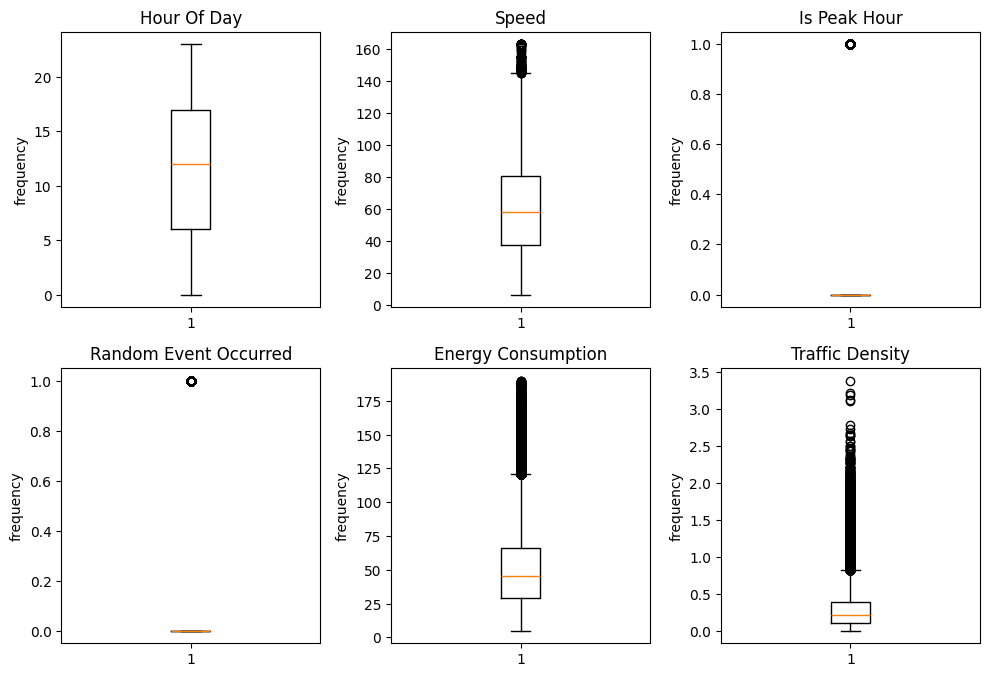

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
for i,col in enumerate(cont_data.columns):
    plt.subplot(3,3,i+1)
    plt.boxplot(cont_data[col])
    plt.title(col)
    plt.ylabel(f"frequency")
plt.tight_layout()
plt.show()

In [15]:
import numpy as np
def remove_outliers(columns):
    for column in columns:
        lower_quantile=cont_data[column].quantile(.25)
        upper_quantile=cont_data[column].quantile(.75)
        
        IQR=upper_quantile-lower_quantile

        upper_boundary = upper_quantile+1.5*IQR
        lower_boundary = lower_quantile-1.5*IQR
 #fitting the outliers into the dataframe
        cont_data[column]=np.where(cont_data[column]>upper_boundary,upper_boundary,cont_data[column])
        cont_data[column]=np.where(cont_data[column]<lower_boundary,lower_boundary,cont_data[column])


In [16]:
remove_outliers(["Speed","Is Peak Hour","Random Event Occurred","Energy Consumption","Traffic Density"])

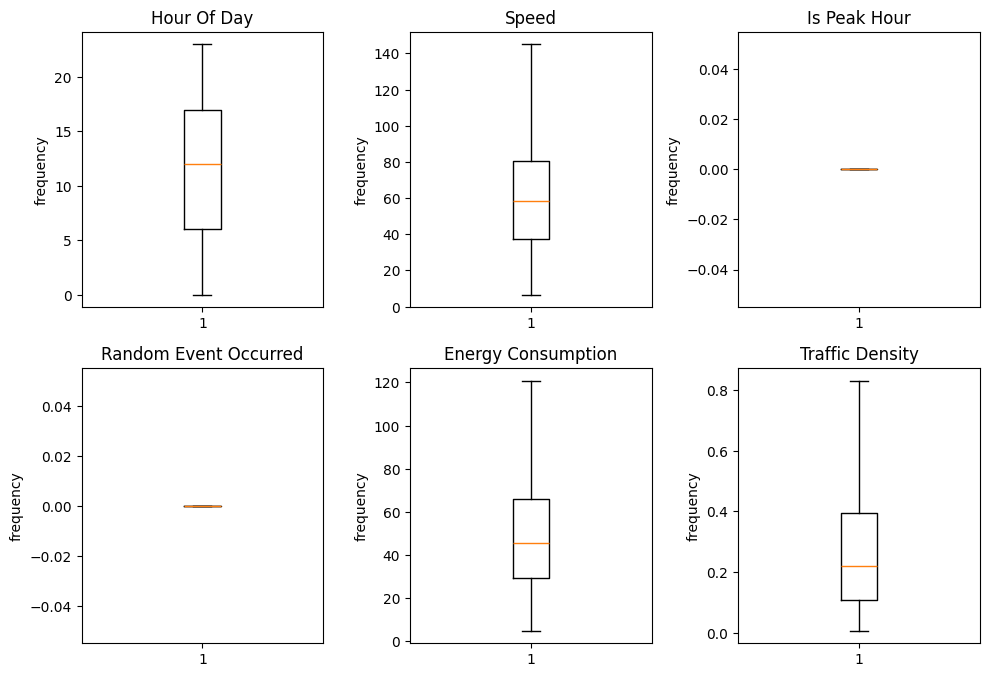

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
for i,col in enumerate(cont_data.columns):
    plt.subplot(3,3,i+1)
    plt.boxplot(cont_data[col])
    plt.title(col)
    plt.ylabel(f"frequency")
plt.tight_layout()
plt.show()

In [ ]:
# shaping after transformation of the data set
df.shape

(1219567, 11)

In [19]:
# aggregating traffic by density
density_by_day = df.groupby('Day Of Week')['Traffic Density'].agg(['mean', 'median', 'std'])
density_by_day

,mean,median,std
Day Of Week,,,
Friday,0.280504,0.2192,0.224672
Monday,0.273950,0.2149,0.215556
Saturday,0.283474,0.2270,0.225341
Sunday,0.283350,0.2269,0.225766
Thursday,0.272366,0.2133,0.213735
Tuesday,0.272943,0.2152,0.214196
Wednesday,0.273143,0.2148,0.213689


In [20]:
# reordering days logically
density_by_day = density_by_day.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
density_by_day

,mean,median,std
Day Of Week,,,
Monday,0.273950,0.2149,0.215556
Tuesday,0.272943,0.2152,0.214196
Wednesday,0.273143,0.2148,0.213689
Thursday,0.272366,0.2133,0.213735
Friday,0.280504,0.2192,0.224672
Saturday,0.283474,0.2270,0.225341
Sunday,0.283350,0.2269,0.225766


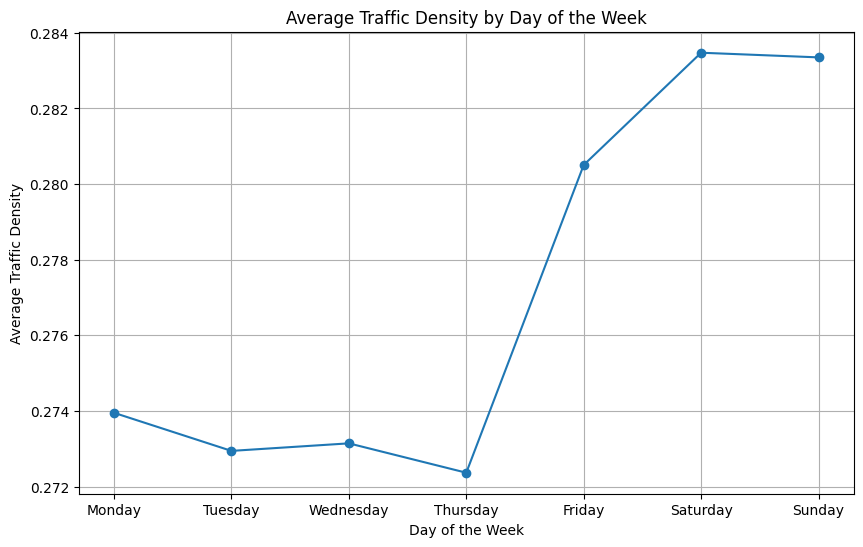

In [21]:
import matplotlib.pyplot as plt
# visualizing the average traffic density by day
plt.figure(figsize=(10,6))
plt.plot(density_by_day.index, density_by_day['mean'], marker='o')
plt.title('Average Traffic Density by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Traffic Density')
plt.grid()
plt.show()


Explanation:
Weekdays show a higher density than weekends, indicating commuter influence.

Question 2: Analyzing the Impact of Various Factors like Weather, Economic Conditions, and Vehicle Types on Traffic Density and Energy Consumption [10 Marks]

- This question wants me to investigate relationships between specific independent variables and two dependent variables (traffic density and energy consumption)
- How cahnges in one affect the others

In [ ]:
# statistical summary of the dataset
df.describe() 

,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density
count,1.219567e+06,1.219567e+06,1.219567e+06,1.219567e+06,1.219567e+06,1.219567e+06
mean,1.150817e+01,5.994476e+01,1.546992e-01,4.988738e-02,4.946464e+01,2.770960e-01
std,6.919071e+00,2.663203e+01,3.616178e-01,2.177123e-01,2.528014e+01,2.191019e-01
min,0.000000e+00,6.693400e+00,0.000000e+00,0.000000e+00,4.929600e+00,5.900000e-03
25%,6.000000e+00,3.753310e+01,0.000000e+00,0.000000e+00,2.927395e+01,1.059000e-01
50%,1.200000e+01,5.847110e+01,0.000000e+00,0.000000e+00,4.578260e+01,2.186000e-01
75%,1.700000e+01,8.053455e+01,0.000000e+00,0.000000e+00,6.590550e+01,3.960000e-01
max,2.300000e+01,1.630886e+02,1.000000e+00,1.000000e+00,1.899489e+02,3.377600e+00


In [25]:
df.columns

Index(['City', 'Vehicle Type', 'Weather', 'Economic Condition', 'Day Of Week',
       'Hour Of Day', 'Speed', 'Is Peak Hour', 'Random Event Occurred',
       'Energy Consumption', 'Traffic Density'],
      dtype='object')

In [ ]:
# encoding categorical variables
df = pd.get_dummies(df, columns=['Weather', 'Vehicle Type', 'Economic Condition'], drop_first=True)  

In [44]:
df.head()

,City,Day Of Week,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density,Weather_Electromagnetic Storm,Weather_Rainy,Weather_Snowy,Weather_Solar Flare,Vehicle Type_Car,Vehicle Type_Drone,Vehicle Type_Flying Car,Economic Condition_Recession,Economic Condition_Stable
0,SolarisVille,Sunday,20,29.4268,0,0,14.7134,0.5241,False,False,True,False,False,True,False,False,True
1,AquaCity,Wednesday,2,118.8000,0,0,143.5682,0.3208,False,False,False,True,False,False,True,True,False
2,Neuroburg,Wednesday,16,100.3904,0,0,91.2640,0.0415,False,False,False,True,False,False,False,True,False
3,Ecoopolis,Thursday,8,76.8000,1,0,46.0753,0.1811,False,False,False,False,False,True,False,False,False
4,AquaCity,Saturday,16,45.2176,0,0,40.1934,0.4544,False,False,False,True,False,False,False,False,True


they have been encoded successfully

In [59]:
# Mean values by weather (using encoded columns)
weather_impact = df.groupby('Weather_Rainy')[['Traffic Density', 'Energy Consumption']].mean()
print("Impact by Rainy Weather (True/False):")
print(weather_impact)

weather_impact = df.groupby('Weather_Solar Flare')[['Traffic Density', 'Energy Consumption']].mean()
print("Impact by Solar Flare (True/False):")
print(weather_impact)

weather_impact = df.groupby('Weather_Snowy')[['Traffic Density', 'Energy Consumption']].mean()
print("Impact by Snowy Weather (True/False):")
print(weather_impact)

weather_impact = df.groupby('Weather_Electromagnetic Storm')[['Traffic Density', 'Energy Consumption']].mean()
print("Impact by Electromagnetic Storm(True/False):")
print(weather_impact)


vehicle_impact = df.groupby('Vehicle Type_Car')[['Traffic Density', 'Energy Consumption']].mean()
print("Impact by Car (True/False):")
print(vehicle_impact)

vehicle_impact = df.groupby('Vehicle Type_Drone')[['Traffic Density', 'Energy Consumption']].mean()
print("Impact by Drone (True/False):")
print(vehicle_impact)

vehicle_impact = df.groupby('Vehicle Type_Flying Car')[['Traffic Density', 'Energy Consumption']].mean()
print("Impact by Electric Truck (True/False):")
print(vehicle_impact)

economic_impact = df.groupby('Economic Condition_Recession')[['Traffic Density', 'Energy Consumption']].mean()
print("Impact by Recession (True/False):")
print(economic_impact)

economic_impact = df.groupby('Economic Condition_Stable')[['Traffic Density', 'Energy Consumption']].mean()
print("Impact by Economic Stable (True/False):")
print(economic_impact)

Impact by Rainy Weather (True/False):
               Traffic Density  Energy Consumption
Weather_Rainy                                     
False                 0.279444           50.179473
True                  0.267690           46.601126
Impact by Solar Flare (True/False):
                     Traffic Density  Energy Consumption
Weather_Solar Flare                                     
False                       0.280694           48.920300
True                        0.262726           51.638399
Impact by Snowy Weather (True/False):
               Traffic Density  Energy Consumption
Weather_Snowy                                     
False                 0.279326           50.335501
True                  0.268190           45.986222
Impact by Electromagnetic Storm(True/False):
                               Traffic Density  Energy Consumption
Weather_Electromagnetic Storm                                     
False                                 0.273611           48.944363
True  

Visualizations

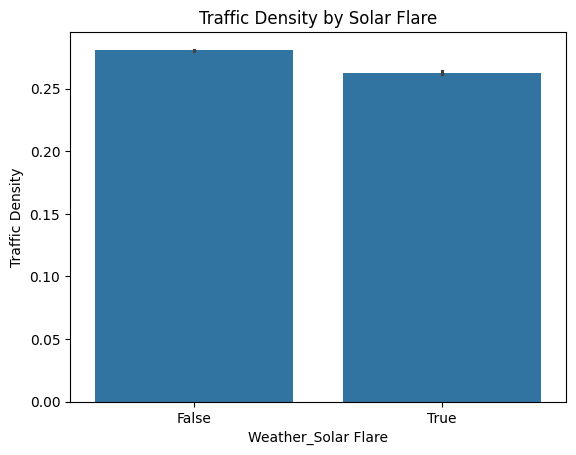

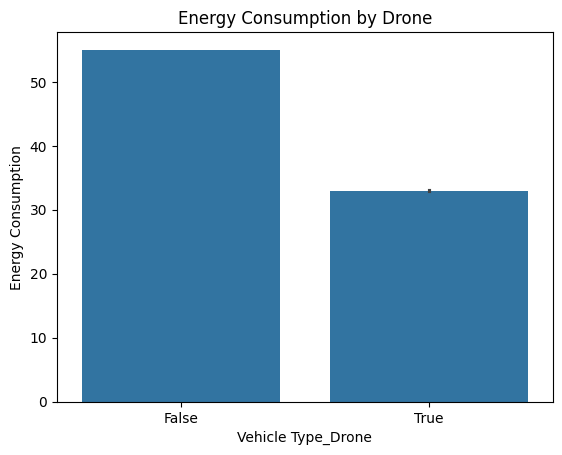

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Traffic density by weather (example with Solar Flare)
sns.barplot(x='Weather_Solar Flare', y='Traffic Density', data=df)
plt.title('Traffic Density by Solar Flare')
plt.show()

# Energy consumption by vehicle type (example with Drone)
sns.barplot(x='Vehicle Type_Drone', y='Energy Consumption', data=df)
plt.title('Energy Consumption by Drone')
plt.show()


Quantifying impacts

Using regression to measure the effect of each factor, leveraging your encoded variables.

In [ ]:
import statsmodels.api as sm

# Define independent variables (X) with all encoded columns
X = df[['Weather_Rainy', 'Weather_Snowy', 'Weather_Solar Flare', 'Weather_Electromagnetic Storm',
        'Vehicle Type_Car', 'Vehicle Type_Drone', 'Vehicle Type_Flying Car', 
        'Economic Condition_Recession', 'Economic Condition_Stable']]
X = sm.add_constant(X)  # Add intercept

# Dependent variable
y_density = df['Traffic Density']

# Ensure alignment and numeric types
X = X.loc[y_density.index]  # Align rows
X = X.astype(float)         # Ensure numeric
y_density = y_density.astype(float)  # Ensure numeric

# Fit the model
model_density = sm.OLS(y_density, X).fit()
print("Regression Results for Traffic Density:")
print(model_density.summary())


y_energy = df['Energy Consumption']
y_energy = y_energy.astype(float)
y_energy = y_energy.loc[X.index]  # Align with X
model_energy = sm.OLS(y_energy, X).fit()
print("Regression Results for Energy Consumption:")
print(model_energy.summary())

Regression Results for Traffic Density:
                            OLS Regression Results                            
Dep. Variable:        Traffic Density   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                 5.133e+04
Date:                Tue, 21 Oct 2025   Prob (F-statistic):               0.00
Time:                        14:12:05   Log-Likelihood:             3.1694e+05
No. Observations:             1219567   AIC:                        -6.339e+05
Df Residuals:                 1219557   BIC:                        -6.337e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------